# Image Classification with CNN for Malaria Data

### Introduction
In this notebook, we perform image classification on malaria cell images using Convolutional Neural Networks (CNN). The steps involved in this process are as follows:

1. Data Loading and Preprocessing:
    * We load the images from the cell_images/cell_images directory.
    * Each image is resized to 64x64 pixels and normalized.
    * Labels are extracted from the directory names, with Parasitized labeled as 1 and Uninfected labeled as 0.
2. Data Visualization:
    * We visualize some of the images along with their labels to understand the dataset better.
3. Model Building:
    * We build a CNN model using TensorFlow and Keras.
    * The model consists of convolutional layers, max-pooling layers, batch normalization, dropout, and dense layers.
4. Data Splitting:

    * The dataset is split into training and testing sets using train_test_split.
5. Model Training:

    * The model is trained using the training set.
    * We use early stopping to prevent overfitting.
 6. Model Evaluation:

    * The model is evaluated on the testing set to determine its accuracy and loss.
7. Data Augmentation:

    * We apply data augmentation techniques to improve the model's performance.
    * Techniques such as rotation, width shift, height shift, horizontal flip, and zoom are used.

In [1]:
import os
import glob
from PIL import Image
import numpy as np

# Define the path to the dataset
dataset_path = 'cell_images/cell_images'

# Get list of all image files in the dataset directory
image_files = glob.glob(os.path.join(dataset_path, '**', '*.png'), recursive=True)

# Function to load and preprocess images and extract labels
def load_images_and_labels(image_files):
    images = []
    labels = []
    for file in image_files:
        img = Image.open(file)
        img = img.resize((64, 64))  # Resize image to 64x64
        img = np.array(img) / 255.0  # Normalize pixel values
        images.append(img)
        
        # Extract label from the parent directory name
        if 'Parasitized' in file:
            labels.append(1)  # Parasitized is 1
        elif 'Uninfected' in file:
            labels.append(0)  # Uninfected is 0
        
    return np.array(images), np.array(labels)

# Load images and labels
images, labels = load_images_and_labels(image_files)

print(f'Total images loaded: {len(images)}')
print(f'Numeric Labels: {labels[:5]}')

Total images loaded: 27558
Numeric Labels: [1 1 1 1 1]


In [2]:
print("last 5 images label" , labels[-5:])
print("first 5 images label" , labels[:5])

last 5 images label [0 0 0 0 0]
first 5 images label [1 1 1 1 1]


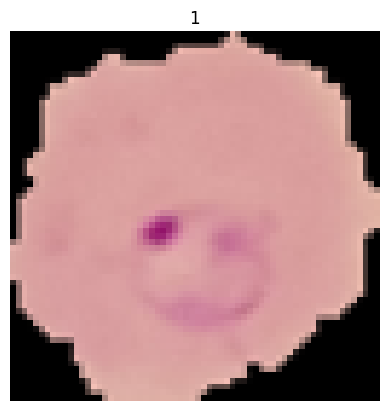

In [3]:
# plot first image
import matplotlib.pyplot as plt
plt.imshow(images[0])
plt.title(labels[0])
plt.axis('off')
plt.show()


In [4]:
# first image and label
print(images[0].shape)
print(labels[0])


(64, 64, 3)
1


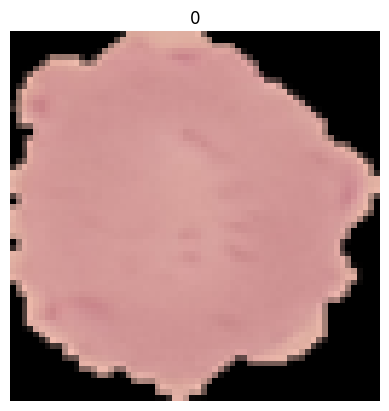

In [5]:
plt.imshow(images[-1])
plt.title(labels[-1])
plt.axis('off')
plt.show()

In [6]:
print(labels[-30:-20])

[0 0 0 0 0 0 0 0 0 0]


In [7]:
# data shape
print(images.shape)
print(labels.shape)


(27558, 64, 64, 3)
(27558,)


In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Conv2D, MaxPooling2D,InputLayer, Reshape , BatchNormalization, Dropout

In [9]:
model = Sequential()
model.add(InputLayer(input_shape=(64,64,3)))
model.add(BatchNormalization())
model.add(Conv2D(32, kernel_size=(3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Conv2D(64, kernel_size=(3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Flatten())
model.add(BatchNormalization())
model.add(Dropout(0.3))
model.add(Dense(120, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(2, activation='softmax'))

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


c:\Users\bugra\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\input_layer.py:26: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


In [10]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(images, labels, test_size=0.2, random_state=42)

# Convert labels to one-hot encoding
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

# Train the model
model.fit(X_train, y_train, epochs=5, validation_data=(X_test, y_test))

# Evaluate the model
loss, accuracy = model.evaluate(X_test, y_test)
print(f'Loss: {loss}, Accuracy: {accuracy}')


Epoch 1/5
689/689 ━━━━━━━━━━━━━━━━━━━━ 57s 80ms/step - accuracy: 0.7897 - loss: 0.6567 - val_accuracy: 0.9487 - val_loss: 0.1626
Epoch 2/5
689/689 ━━━━━━━━━━━━━━━━━━━━ 51s 73ms/step - accuracy: 0.9450 - loss: 0.1624 - val_accuracy: 0.9487 - val_loss: 0.1574
Epoch 3/5
689/689 ━━━━━━━━━━━━━━━━━━━━ 52s 75ms/step - accuracy: 0.9502 - loss: 0.1484 - val_accuracy: 0.9336 - val_loss: 0.1815
Epoch 4/5
689/689 ━━━━━━━━━━━━━━━━━━━━ 60s 87ms/step - accuracy: 0.9496 - loss: 0.1419 - val_accuracy: 0.9508 - val_loss: 0.1713
Epoch 5/5
689/689 ━━━━━━━━━━━━━━━━━━━━ 53s 77ms/step - accuracy: 0.9558 - loss: 0.1231 - val_accuracy: 0.9450 - val_loss: 0.1876
173/173 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.9443 - loss: 0.1817
Loss: 0.18758971989154816, Accuracy: 0.9450290203094482


In [11]:
# Initialize Early Stopping
from tensorflow.keras.callbacks import EarlyStopping
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train the model
history = model.fit(X_train, y_train, epochs=50,  # Eğitim süresini artırabilirsiniz
                    validation_data=(X_test, y_test),
                    callbacks=[early_stopping])

# Evaluate the model
loss, accuracy = model.evaluate(X_test, y_test)
print(f'Loss: {loss}, Accuracy: {accuracy}')


Epoch 1/50
689/689 ━━━━━━━━━━━━━━━━━━━━ 49s 71ms/step - accuracy: 0.9560 - loss: 0.1251 - val_accuracy: 0.9503 - val_loss: 0.1618
Epoch 2/50
689/689 ━━━━━━━━━━━━━━━━━━━━ 48s 70ms/step - accuracy: 0.9579 - loss: 0.1150 - val_accuracy: 0.9487 - val_loss: 0.1679
Epoch 3/50
689/689 ━━━━━━━━━━━━━━━━━━━━ 49s 71ms/step - accuracy: 0.9665 - loss: 0.1012 - val_accuracy: 0.9425 - val_loss: 0.1918
Epoch 4/50
689/689 ━━━━━━━━━━━━━━━━━━━━ 46s 67ms/step - accuracy: 0.9640 - loss: 0.0997 - val_accuracy: 0.9461 - val_loss: 0.2031
Epoch 5/50
689/689 ━━━━━━━━━━━━━━━━━━━━ 47s 69ms/step - accuracy: 0.9661 - loss: 0.0972 - val_accuracy: 0.9416 - val_loss: 0.2434
Epoch 6/50
689/689 ━━━━━━━━━━━━━━━━━━━━ 55s 80ms/step - accuracy: 0.9639 - loss: 0.1010 - val_accuracy: 0.9465 - val_loss: 0.2358
173/173 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.9523 - loss: 0.1545
Loss: 0.1617554873228073, Accuracy: 0.9502902626991272


In [12]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping

# Veri Artırma (Data Augmentation)
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    horizontal_flip=True,
    zoom_range=0.15
)

datagen.fit(X_train)

# Erken Durdurma (Early Stopping)
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Modeli Eğitme
history = model.fit(datagen.flow(X_train, y_train, batch_size=64),
                    epochs=50,
                    validation_data=(X_test, y_test),
                    callbacks=[early_stopping])


Epoch 1/50


c:\Users\bugra\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


345/345 ━━━━━━━━━━━━━━━━━━━━ 50s 142ms/step - accuracy: 0.9190 - loss: 0.2392 - val_accuracy: 0.9543 - val_loss: 0.1451
Epoch 2/50
345/345 ━━━━━━━━━━━━━━━━━━━━ 52s 151ms/step - accuracy: 0.9333 - loss: 0.1983 - val_accuracy: 0.9510 - val_loss: 0.1544
Epoch 3/50
345/345 ━━━━━━━━━━━━━━━━━━━━ 53s 152ms/step - accuracy: 0.9331 - loss: 0.1917 - val_accuracy: 0.9532 - val_loss: 0.1463
Epoch 4/50
345/345 ━━━━━━━━━━━━━━━━━━━━ 51s 148ms/step - accuracy: 0.9389 - loss: 0.1815 - val_accuracy: 0.9521 - val_loss: 0.1495
Epoch 5/50
345/345 ━━━━━━━━━━━━━━━━━━━━ 49s 142ms/step - accuracy: 0.9359 - loss: 0.1807 - val_accuracy: 0.9546 - val_loss: 0.1351
Epoch 6/50
345/345 ━━━━━━━━━━━━━━━━━━━━ 55s 158ms/step - accuracy: 0.9397 - loss: 0.1805 - val_accuracy: 0.9537 - val_loss: 0.1491
Epoch 7/50
345/345 ━━━━━━━━━━━━━━━━━━━━ 56s 162ms/step - accuracy: 0.9378 - loss: 0.1858 - val_accuracy: 0.9514 - val_loss: 0.1532
Epoch 8/50
345/345 ━━━━━━━━━━━━━━━━━━━━ 55s 158ms/step - accuracy: 0.9410 - loss: 0.1781 - val

In [13]:
model = Sequential()
model.add(InputLayer(input_shape=(64,64,3)))
model.add(BatchNormalization())
model.add(Conv2D(32, kernel_size=(3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Conv2D(64, kernel_size=(3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Flatten())
model.add(BatchNormalization())
model.add(Dropout(0.3))
model.add(Dense(720, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(120, activation='relu'))
model.add(Dense(2, activation='softmax'))

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


c:\Users\bugra\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\input_layer.py:26: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


In [14]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(images, labels, test_size=0.2, random_state=42)

# Convert labels to one-hot encoding
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

# Train the model
model.fit(X_train, y_train, epochs=5, validation_data=(X_test, y_test))

# Evaluate the model
loss, accuracy = model.evaluate(X_test, y_test)
print(f'Loss: {loss}, Accuracy: {accuracy}')


Epoch 1/5
689/689 ━━━━━━━━━━━━━━━━━━━━ 128s 179ms/step - accuracy: 0.7336 - loss: 0.7509 - val_accuracy: 0.8939 - val_loss: 0.2894
Epoch 2/5
689/689 ━━━━━━━━━━━━━━━━━━━━ 116s 168ms/step - accuracy: 0.9435 - loss: 0.1618 - val_accuracy: 0.9432 - val_loss: 0.1847
Epoch 3/5
689/689 ━━━━━━━━━━━━━━━━━━━━ 115s 167ms/step - accuracy: 0.9489 - loss: 0.1470 - val_accuracy: 0.9536 - val_loss: 0.1443
Epoch 4/5
689/689 ━━━━━━━━━━━━━━━━━━━━ 121s 175ms/step - accuracy: 0.9531 - loss: 0.1323 - val_accuracy: 0.9532 - val_loss: 0.1470
Epoch 5/5
689/689 ━━━━━━━━━━━━━━━━━━━━ 112s 163ms/step - accuracy: 0.9574 - loss: 0.1187 - val_accuracy: 0.9516 - val_loss: 0.1606
173/173 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.9521 - loss: 0.1574
Loss: 0.16057416796684265, Accuracy: 0.9515602588653564


In [15]:
# Initialize Early Stopping
from tensorflow.keras.callbacks import EarlyStopping
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train the model
history = model.fit(X_train, y_train, epochs=50,  # Eğitim süresini artırabilirsiniz
                    validation_data=(X_test, y_test),
                    callbacks=[early_stopping])

# Evaluate the model
loss, accuracy = model.evaluate(X_test, y_test)
print(f'Loss: {loss}, Accuracy: {accuracy}')


Epoch 1/50
689/689 ━━━━━━━━━━━━━━━━━━━━ 118s 172ms/step - accuracy: 0.9600 - loss: 0.1166 - val_accuracy: 0.9530 - val_loss: 0.1600
Epoch 2/50
689/689 ━━━━━━━━━━━━━━━━━━━━ 110s 160ms/step - accuracy: 0.9633 - loss: 0.1003 - val_accuracy: 0.9447 - val_loss: 0.1783
Epoch 3/50
689/689 ━━━━━━━━━━━━━━━━━━━━ 100s 146ms/step - accuracy: 0.9672 - loss: 0.0924 - val_accuracy: 0.9508 - val_loss: 0.1691
Epoch 4/50
689/689 ━━━━━━━━━━━━━━━━━━━━ 101s 146ms/step - accuracy: 0.9696 - loss: 0.0813 - val_accuracy: 0.9566 - val_loss: 0.1686
Epoch 5/50
689/689 ━━━━━━━━━━━━━━━━━━━━ 106s 154ms/step - accuracy: 0.9740 - loss: 0.0722 - val_accuracy: 0.9528 - val_loss: 0.1677
Epoch 6/50
689/689 ━━━━━━━━━━━━━━━━━━━━ 111s 161ms/step - accuracy: 0.9768 - loss: 0.0690 - val_accuracy: 0.9492 - val_loss: 0.2098
173/173 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.9550 - loss: 0.1520
Loss: 0.1600223332643509, Accuracy: 0.9530116319656372


In [16]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping

# Veri Artırma (Data Augmentation)
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    horizontal_flip=True,
    zoom_range=0.15
)

datagen.fit(X_train)

# Erken Durdurma (Early Stopping)
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Modeli Eğitme
history = model.fit(datagen.flow(X_train, y_train, batch_size=64),
                    epochs=50,
                    validation_data=(X_test, y_test),
                    callbacks=[early_stopping])


Epoch 1/50
345/345 ━━━━━━━━━━━━━━━━━━━━ 79s 225ms/step - accuracy: 0.9242 - loss: 0.2194 - val_accuracy: 0.9570 - val_loss: 0.1504
Epoch 2/50
345/345 ━━━━━━━━━━━━━━━━━━━━ 88s 254ms/step - accuracy: 0.9363 - loss: 0.1898 - val_accuracy: 0.9597 - val_loss: 0.1271
Epoch 3/50
345/345 ━━━━━━━━━━━━━━━━━━━━ 89s 256ms/step - accuracy: 0.9383 - loss: 0.1836 - val_accuracy: 0.9565 - val_loss: 0.1281
Epoch 4/50
345/345 ━━━━━━━━━━━━━━━━━━━━ 86s 249ms/step - accuracy: 0.9425 - loss: 0.1734 - val_accuracy: 0.9570 - val_loss: 0.1262
Epoch 5/50
345/345 ━━━━━━━━━━━━━━━━━━━━ 90s 260ms/step - accuracy: 0.9401 - loss: 0.1772 - val_accuracy: 0.9561 - val_loss: 0.1381
Epoch 6/50
345/345 ━━━━━━━━━━━━━━━━━━━━ 104s 299ms/step - accuracy: 0.9432 - loss: 0.1684 - val_accuracy: 0.9581 - val_loss: 0.1284
Epoch 7/50
345/345 ━━━━━━━━━━━━━━━━━━━━ 101s 290ms/step - accuracy: 0.9430 - loss: 0.1665 - val_accuracy: 0.9559 - val_loss: 0.1448
Epoch 8/50
345/345 ━━━━━━━━━━━━━━━━━━━━ 134s 388ms/step - accuracy: 0.9429 - loss

In [17]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f'Loss: {loss}, Accuracy: {accuracy}')

173/173 ━━━━━━━━━━━━━━━━━━━━ 6s 33ms/step - accuracy: 0.9600 - loss: 0.1191
Loss: 0.11962030082941055, Accuracy: 0.9597242474555969


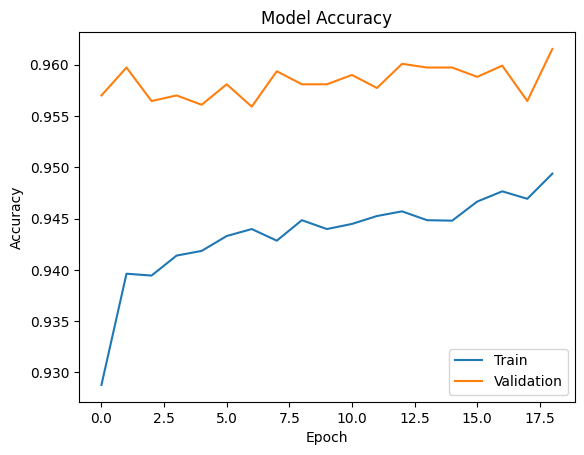

In [18]:
# plot accuray  by epoch
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='lower right')
plt.show()



In [19]:
# save model
model.save('malaria_model_with_data_augmentation_and_early_stopping.h5')



## Conclusion

After training and evaluating the CNN model, we achieved the following results:

- **Initial Model**:
  - The initial model without data augmentation achieved a certain level of accuracy and loss on the testing set.

- **Model with Data Augmentation**:
  - By applying data augmentation techniques, we observed an improvement in the model's performance.
  - The model with data augmentation showed better generalization and higher accuracy compared to the initial model.

**Best Method**:
- The best method for this task was the CNN model with data augmentation. The use of data augmentation techniques significantly improved the model's ability to generalize to new, unseen data, resulting in higher accuracy and lower loss on the testing set.

Overall, the CNN model with data augmentation proved to be the most effective approach for classifying malaria cell images in this study.